# Exploratory Data Analysis

# Reproducibility

- **Generated at:** `2026-08-06T04:51:08.329076+00:00`
- **Code/commit reference:** `aa84a065ffa36b58a3f8f8b2b8523d7dad07a45c`
- **Dataset row counts used:** orders=99,441, payments=103,886, order_items=112,650, customers=99,441, customer_profile=93,358, reviews=99,224
- **Metric contract:** delivered orders only for revenue, orders, customers, AOV, and historical CLV; purchase timestamp is the date axis.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from app.services.dataframes import query_frame
from app.services.eda_service import run_eda
sns.set_theme(style='whitegrid')
eda = await run_eda()

In [2]:
pd.DataFrame(eda['univariate']).T

,count,mean,median,mode,variance,std,q1,q3,min,max
price,112650.0,120.653739,74.99,59.9,33721.419531,183.633928,39.90,134.9000,0.85,6735.00
freight_value,112650.0,19.990320,16.26,15.1,249.842452,15.806405,13.08,21.1500,0.00,409.68
payment_value,103886.0,154.100380,100.00,50.0,47303.667816,217.494064,56.79,171.8375,0.00,13664.08
delivery_days,96476.0,12.094086,10.00,7.0,91.235854,9.551746,6.00,15.0000,0.00,209.00
review_score,98410.0,4.088802,5.00,5.0,1.811064,1.345758,4.00,5.0000,1.00,5.00


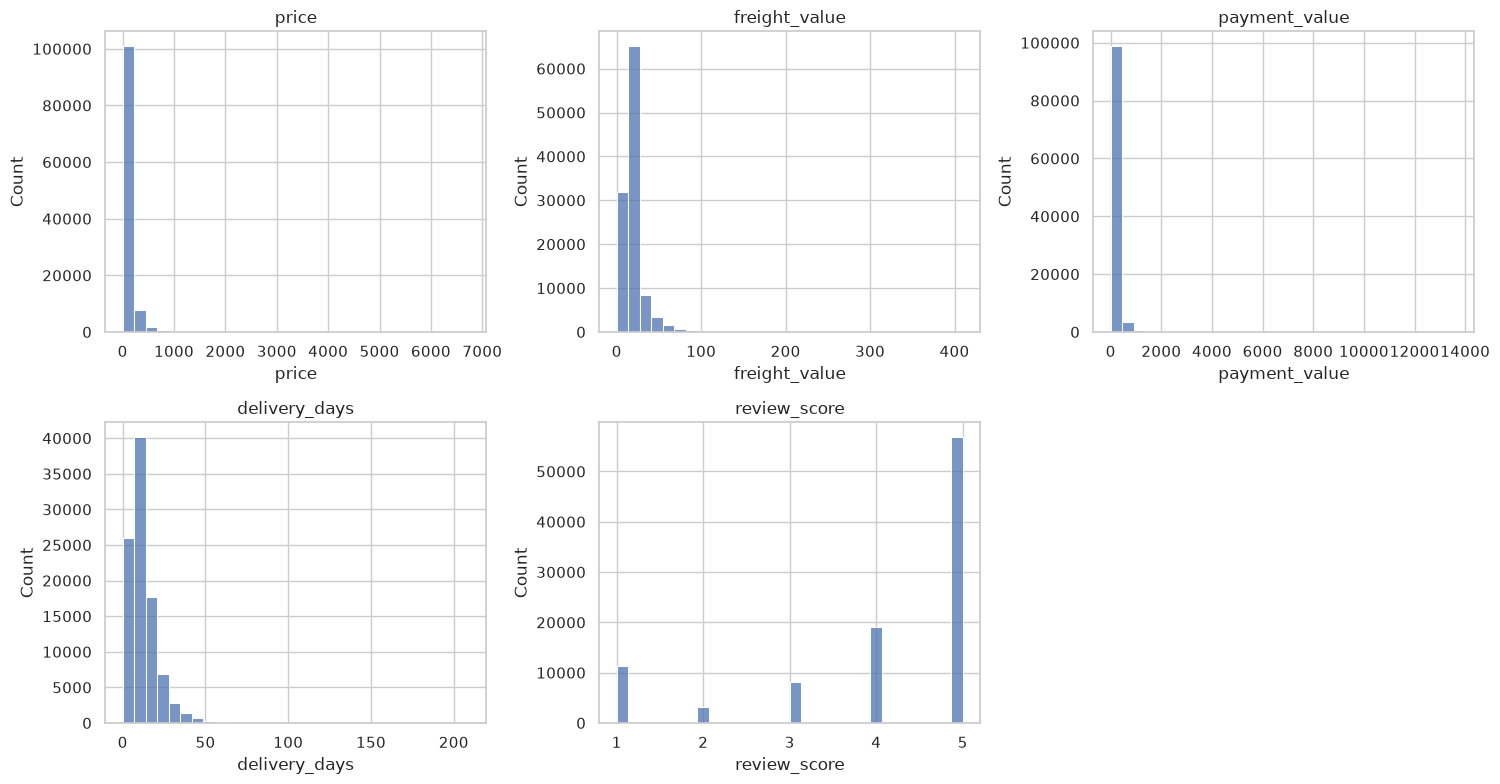

In [3]:
items = await query_frame('SELECT price, freight_value FROM curated.order_items')
payments = await query_frame('SELECT payment_value FROM curated.payment_details')
delivery = await query_frame('SELECT delivery_days FROM curated.orders WHERE delivery_days IS NOT NULL')
reviews = await query_frame("SELECT review_score FROM (SELECT DISTINCT ON (review_id) review_id, review_score FROM curated.reviews ORDER BY review_id, order_id) x")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, values) in zip(axes.flat, [('price', items.price), ('freight_value', items.freight_value), ('payment_value', payments.payment_value), ('delivery_days', delivery.delivery_days), ('review_score', reviews.review_score)]):
    sns.histplot(pd.to_numeric(values), bins=30, ax=ax)
    ax.set_title(name)
axes.flat[-1].axis('off')
plt.tight_layout()

Text(0.5, 1.0, 'Price vs freight value')

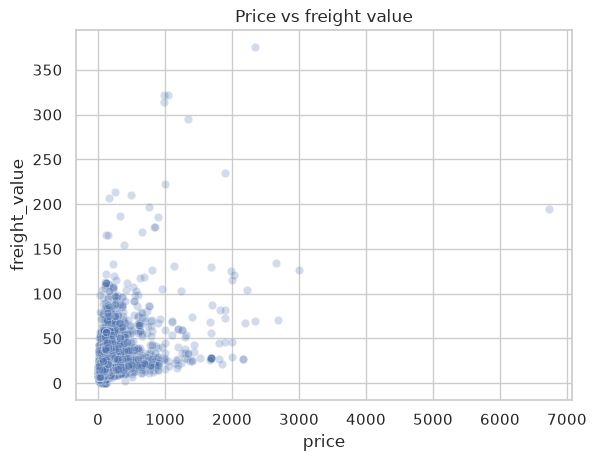

In [4]:
scatter = pd.DataFrame(eda['bivariate']['price_freight_sample'])
sns.scatterplot(data=scatter, x='price', y='freight_value', alpha=.25)
plt.title('Price vs freight value')

Text(0.5, 1.0, 'Review score by delivery outcome')

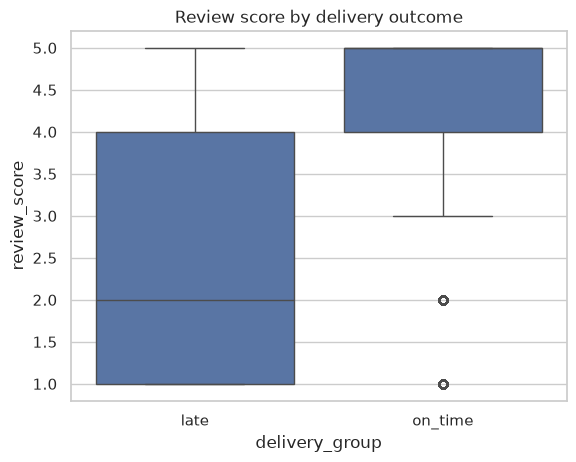

In [5]:
box = await query_frame("SELECT CASE WHEN o.is_late THEN 'late' ELSE 'on_time' END delivery_group, r.review_score FROM curated.orders o JOIN curated.reviews r ON r.order_id=o.order_id WHERE o.order_status='delivered'")
sns.boxplot(data=box, x='delivery_group', y='review_score')
plt.title('Review score by delivery outcome')

In [6]:
pd.DataFrame(eda['bivariate']['payment_type_aov'])

,payment_type,orders,average_order_value
0,credit_card,72825,166.1426140748369379
1,boleto,19191,144.3349856703663175
2,voucher,2977,114.8601276452804837
3,debit_card,1484,140.4468396226415094
4,None,1,143.4600000000000000


Text(0.5, 1.0, 'Pearson correlation matrix')

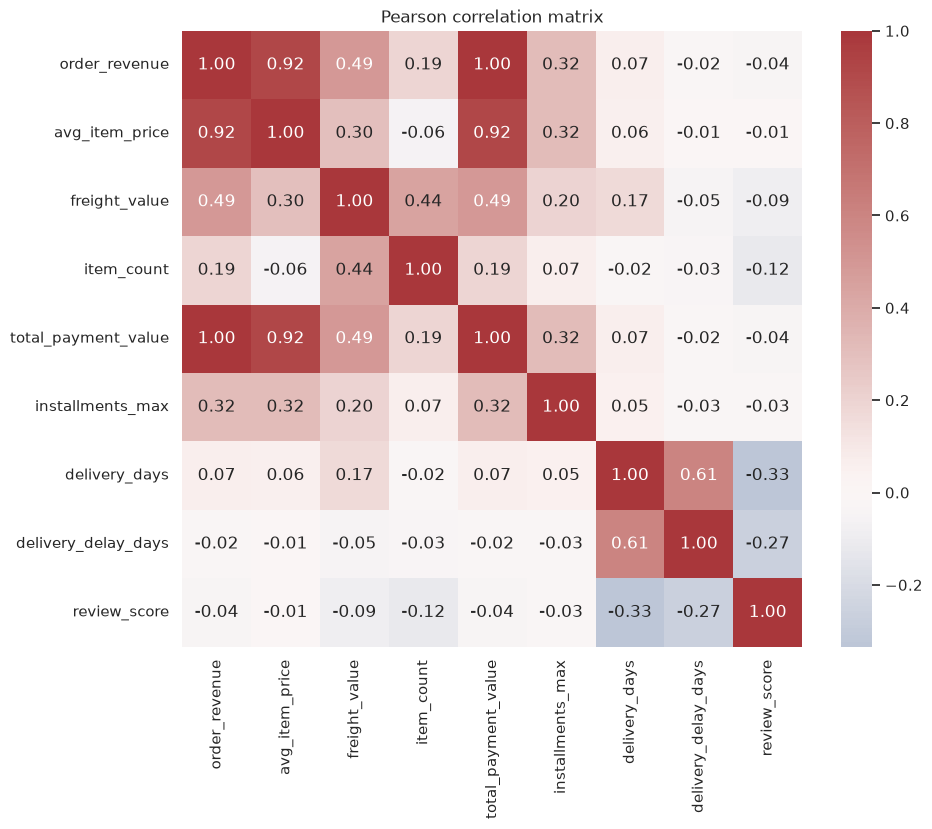

In [7]:
corr = pd.DataFrame(eda['multivariate']['correlation'])
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Pearson correlation matrix')

Text(0, 0.5, 'BRL')

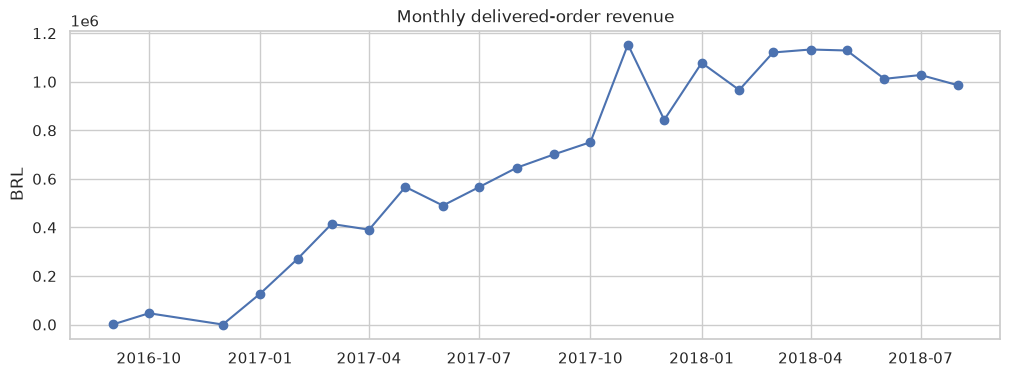

In [8]:
trend = pd.DataFrame(eda['trend'])
trend['month'] = pd.to_datetime(trend['month'])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trend.month, trend.revenue, marker='o')
ax.set_title('Monthly delivered-order revenue')
ax.set_ylabel('BRL')

In [9]:
pd.DataFrame(eda['seasonality']).set_index('month_of_year')

,avg_monthly_revenue,avg_monthly_orders
month_of_year,,
1,602684.915000000000,3909.5000000000000000
2,618703.865000000000,4104.0000000000000000
3,767464.595000000000,4774.5000000000000000
4,761845.665000000000,4550.5000000000000000
5,847812.960000000000,5147.5000000000000000
6,751014.330000000000,4617.0000000000000000
7,797053.180000000000,5015.5000000000000000
8,815662.000000000000,5272.0000000000000000
9,350610.475000000000,2075.5000000000000000


In [10]:
pd.Series(eda['category_outlier_comparison'], name='value')

population                                                        112650
global_price                                                        8427
category_price                                                      9376
price_changed                                                       4071
global_freight                                                     12134
category_freight                                                    9767
freight_changed                                                     4179
price_changed_pct                                               3.613848
freight_changed_pct                                              3.70972
decision               Category-conditional bounds replace global ite...
Name: value, dtype: object

In [11]:
pd.Series(eda['review_duplicate_consistency'], name='groups')

duplicate_groups       789
inconsistent_groups      0
Name: groups, dtype: int64